<a href="https://colab.research.google.com/github/nafilafiryal/data_mining/blob/main/4_CleaningData.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn import model_selection

from google.colab import drive
drive.mount('/content/drive')

data_raw = pd.read_csv('/content/drive/MyDrive/dataMining/train.csv')
data_val = pd.read_csv('/content/drive/MyDrive/dataMining/test.csv')

data1 = data_raw.copy(deep = True)

data_cleaner = [data1, data_val]

print('kolom data Train dengan nilai NULL:\n', data1.isnull().sum())
print("-"*10)

print('kolom data Test dengan nilai NULL:\n', data_val.isnull().sum())
print("-"*10)

data_raw.describe(include = 'all')

print('kolom data Train dengan nilai NULL:\n', data1.isnull().sum())
print("-"*10)

print('kolom data Test dengan nilai NULL:\n', data_val.isnull().sum())
print("-"*10)

data_raw.describe(include = 'all')

Mounted at /content/drive
kolom data Train dengan nilai NULL:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
----------
kolom data Test dengan nilai NULL:
 PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64
----------
kolom data Train dengan nilai NULL:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
----------
kolom data Test dengan nilai NULL:
 PassengerId      0
Pclass           0
Name             0
Sex              0
Age            

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Dooley, Mr. Patrick",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [4]:
for dataset in data_cleaner:
  #isikan age yang kosong dengan median
  dataset['Age'].fillna(dataset['Age'].median(), inplace = True)

  #isikan embarked dengan modus
  dataset['Embarked'].fillna(dataset['Embarked'].mode()[0], inplace = True)

  #isikan fare dengan median
  dataset['Fare'].fillna(dataset['Fare'].median(), inplace = True)

#hapus atribut cabin dan lainnya yang kita anggap tidak diperlukan
drop_column = ['PassengerId', 'Cabin', 'Ticket']
data1.drop(drop_column, axis=1, inplace = True)

print(data1.isnull().sum())
print("-"*10)
print(data_val.isnull().sum())

Survived    0
Pclass      0
Name        0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64
----------
PassengerId      0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          327
Embarked         0
dtype: int64


/tmp/ipykernel_1016/175582639.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['Age'].fillna(dataset['Age'].median(), inplace = True)
/tmp/ipykernel_1016/175582639.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=

In [5]:
for dataset in data_cleaner:
  #variables discrete
  dataset['FamilySize'] = dataset ['SibSp'] + dataset['Parch'] + 1

  dataset['IsAlone'] = 1 #diisikan 1 jika sendiri
  dataset['IsAlone'].loc[dataset['FamilySize'] > 1] = 0 #isikan 0 jika ada relasi yang bersama

  #Pisahkan title dari nama: http://www.pythonforbeginners.com/dictionary/python-split
  dataset['Title'] = dataset['Name'].str.split(", ", expand=True)[1].str.split(".", expand=True)[0]

  #buat bin Fare menggunakan qcut atau bin Frekuensi:
  dataset['FareBin'] = pd.qcut(dataset['Fare'], 4)

  #buat bin Age menggunakan cut or nilai bin:
  dataset['AgeBin'] = pd.cut(dataset['Age'].astype(int), 5)

#bersihkan title yang jarang ada
stat_min = 10
title_names = (data1['Title'].value_counts() < stat_min)

data1['Title'] = data1['Title'].apply(lambda x: 'Misc' if title_names.loc[x] == True else x)
print(data1['Title'].value_counts())
print("-"*10)

#tampilkan data lagi
data1.info()
data_val.info()
data1.sample(10)

Title
Mr        517
Miss      182
Mrs       125
Master     40
Misc       27
Name: count, dtype: int64
----------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   Survived    891 non-null    int64   
 1   Pclass      891 non-null    int64   
 2   Name        891 non-null    object  
 3   Sex         891 non-null    object  
 4   Age         891 non-null    float64 
 5   SibSp       891 non-null    int64   
 6   Parch       891 non-null    int64   
 7   Fare        891 non-null    float64 
 8   Embarked    891 non-null    object  
 9   FamilySize  891 non-null    int64   
 10  IsAlone     891 non-null    int64   
 11  Title       891 non-null    object  
 12  FareBin     891 non-null    category
 13  AgeBin      891 non-null    category
dtypes: category(2), float64(2), int64(6), object(4)
memory usage: 85.9+ KB
<class 'pandas.core.frame.DataFram

/tmp/ipykernel_1016/3999176033.py:6: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  dataset['IsAlone'].loc[dataset['FamilySize'] > 1] = 0 #isikan 0 jika ada relasi yang bersama
/tmp/ipykernel_1016/3999176033.py:6: SettingWithCopyWarning: 
A v

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone,Title,FareBin,AgeBin
807,0,3,"Pettersson, Miss. Ellen Natalia",female,18.0,0,0,7.7750,S,1,1,Miss,"(-0.001, 7.91]","(16.0, 32.0]"
734,0,2,"Troupiansky, Mr. Moses Aaron",male,23.0,0,0,13.0000,S,1,1,Mr,"(7.91, 14.454]","(16.0, 32.0]"
142,1,3,"Hakkarainen, Mrs. Pekka Pietari (Elin Matilda ...",female,24.0,1,0,15.8500,S,2,0,Mrs,"(14.454, 31.0]","(16.0, 32.0]"
62,0,1,"Harris, Mr. Henry Birkhardt",male,45.0,1,0,83.4750,S,2,0,Mr,"(31.0, 512.329]","(32.0, 48.0]"
767,0,3,"Mangan, Miss. Mary",female,30.5,0,0,7.7500,Q,1,1,Miss,"(-0.001, 7.91]","(16.0, 32.0]"
869,1,3,"Johnson, Master. Harold Theodor",male,4.0,1,1,11.1333,S,3,0,Master,"(7.91, 14.454]","(-0.08, 16.0]"
681,1,1,"Hassab, Mr. Hammad",male,27.0,0,0,76.7292,C,1,1,Mr,"(31.0, 512.329]","(16.0, 32.0]"
662,0,1,"Colley, Mr. Edward Pomeroy",male,47.0,0,0,25.5875,S,1,1,Mr,"(14.454, 31.0]","(32.0, 48.0]"
322,1,2,"Slayter, Miss. Hilda Mary",female,30.0,0,0,12.3500,Q,1,1,Miss,"(7.91, 14.454]","(16.0, 32.0]"
659,0,1,"Newell, Mr. Arthur Webster",male,58.0,0,2,113.2750,C,3,0,Mr,"(31.0, 512.329]","(48.0, 64.0]"


In [6]:
# 1. Definisikan Target
Target = ['Survived']

# 2. Definisikan data1_x (Kolom-kolom diskrit/kategorikal hasil dari halaman sebelumnya)
data1_x = ['Sex', 'Pclass', 'Embarked', 'Title', 'SibSp', 'Parch', 'FamilySize', 'IsAlone']

# 3. Jalankan kode dari Jobsheet Halaman 11
for x in data1_x:
  if data1[x].dtype != 'float64' :
    print('Korelasi Survival dengan:', x)
    print(data1[[x, Target[0]]].groupby(x, as_index=False).mean())
    print('-'*10, '\n')

Korelasi Survival dengan: Sex
      Sex  Survived
0  female  0.742038
1    male  0.188908
---------- 

Korelasi Survival dengan: Pclass
   Pclass  Survived
0       1  0.629630
1       2  0.472826
2       3  0.242363
---------- 

Korelasi Survival dengan: Embarked
  Embarked  Survived
0        C  0.553571
1        Q  0.389610
2        S  0.339009
---------- 

Korelasi Survival dengan: Title
    Title  Survived
0  Master  0.575000
1    Misc  0.444444
2    Miss  0.697802
3      Mr  0.156673
4     Mrs  0.792000
---------- 

Korelasi Survival dengan: SibSp
   SibSp  Survived
0      0  0.345395
1      1  0.535885
2      2  0.464286
3      3  0.250000
4      4  0.166667
5      5  0.000000
6      8  0.000000
---------- 

Korelasi Survival dengan: Parch
   Parch  Survived
0      0  0.343658
1      1  0.550847
2      2  0.500000
3      3  0.600000
4      4  0.000000
5      5  0.200000
6      6  0.000000
---------- 

Korelasi Survival dengan: FamilySize
   FamilySize  Survived
0           1  0.30

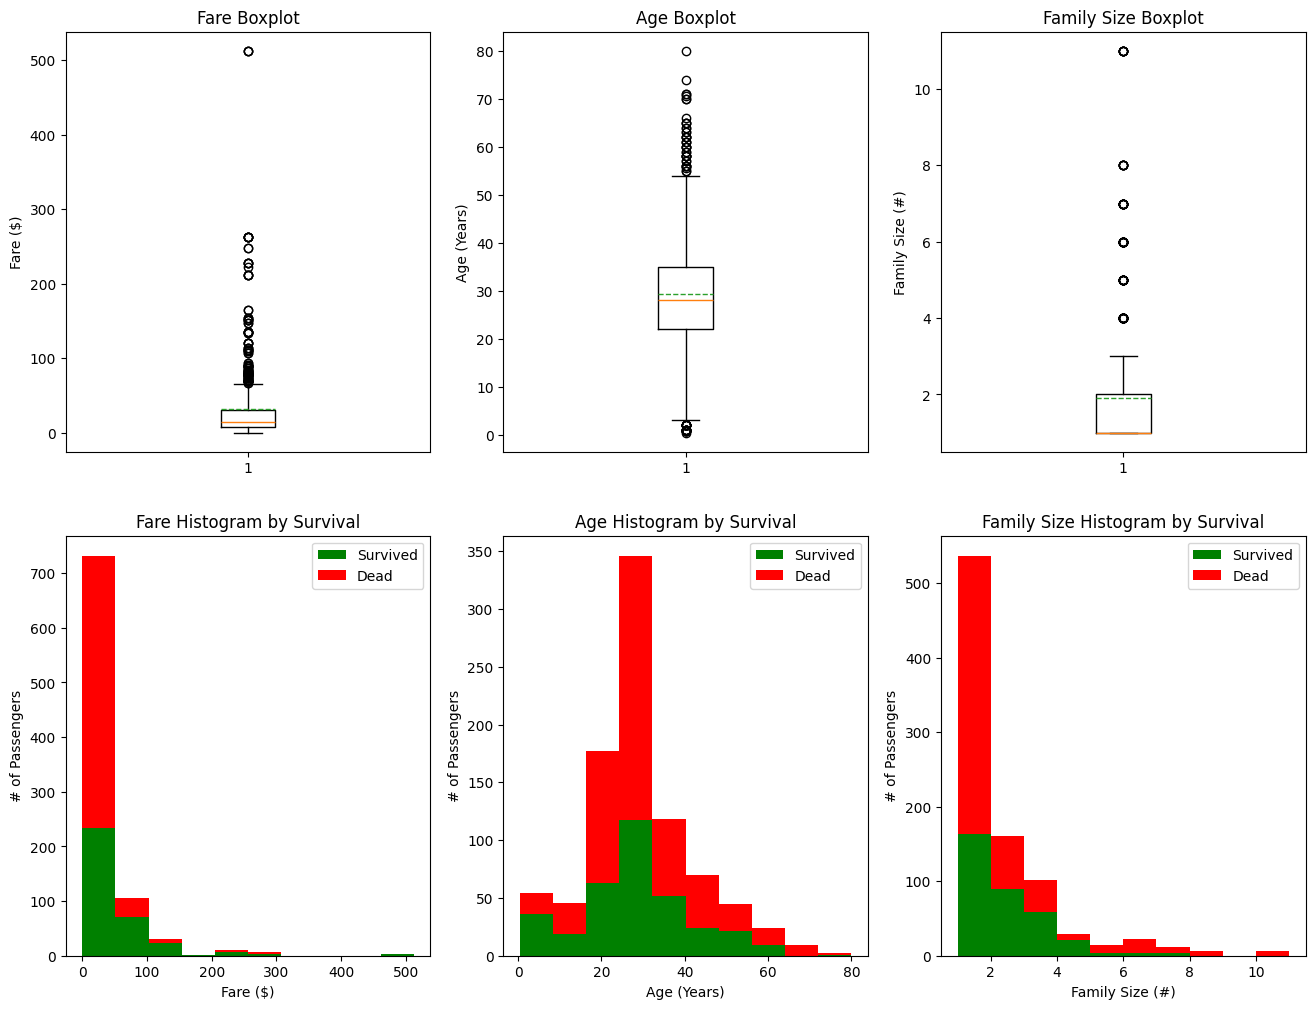

In [7]:
plt.figure(figsize=[16,12])

plt.subplot(231)
plt.boxplot(x=data1['Fare'], showmeans = True, meanline = True)
plt.title('Fare Boxplot')
plt.ylabel('Fare ($)')

plt.subplot(232)
plt.boxplot(data1['Age'], showmeans = True, meanline = True)
plt.title('Age Boxplot')
plt.ylabel('Age (Years)')

plt.subplot(233)
plt.boxplot(data1['FamilySize'], showmeans = True, meanline = True)
plt.title('Family Size Boxplot')
plt.ylabel('Family Size (#)')

plt.subplot(234)
plt.hist(x = [data1[data1['Survived']==1]['Fare'], data1[data1['Survived']==0]['Fare']],
         stacked=True, color = ['g','r'],label = ['Survived','Dead'])
plt.title('Fare Histogram by Survival')
plt.xlabel('Fare ($)')
plt.ylabel('# of Passengers')
plt.legend()

plt.subplot(235)
plt.hist(x = [data1[data1['Survived']==1]['Age'], data1[data1['Survived']==0]['Age']],
         stacked=True, color = ['g','r'],label = ['Survived','Dead'])
plt.title('Age Histogram by Survival')
plt.xlabel('Age (Years)')
plt.ylabel('# of Passengers')
plt.legend()

plt.subplot(236)
plt.hist(x = [data1[data1['Survived']==1]['FamilySize'], data1[data1['Survived']==0]['FamilySize']],
         stacked=True, color = ['g','r'],label = ['Survived','Dead'])
plt.title('Family Size Histogram by Survival')
plt.xlabel('Family Size (#)')
plt.ylabel('# of Passengers')
plt.legend()

<Axes: xlabel='FamilySize', ylabel='Survived'>

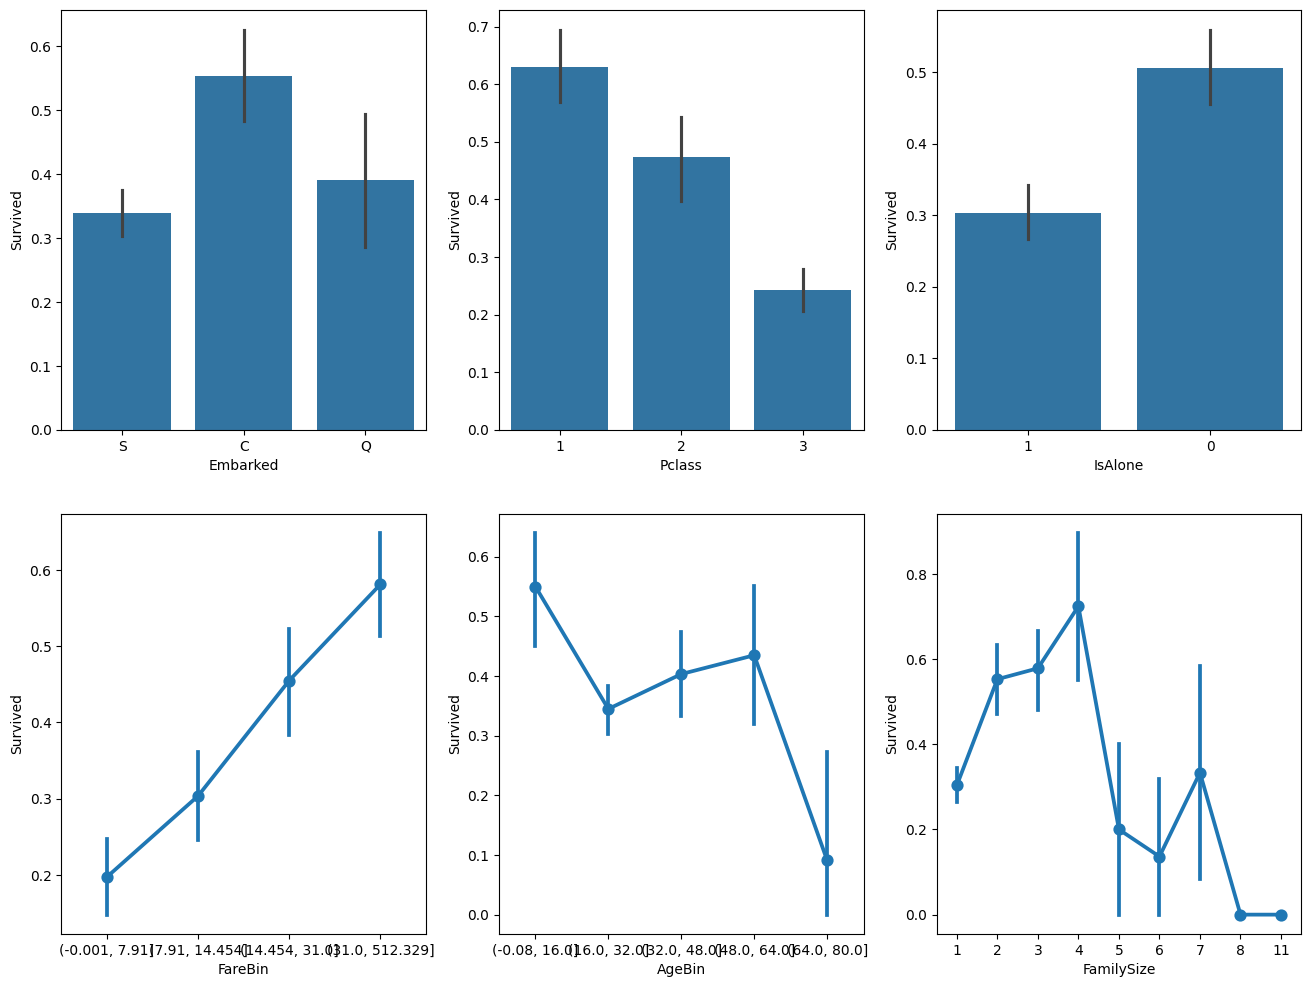

In [8]:
#kita gunakan seaborn untuk perbandingan antar variabel: https://seaborn.pydata.org/api.html
#graph individual features dengan survival
fig, saxis = plt.subplots(2, 3,figsize=(16,12))

sns.barplot(x = 'Embarked', y = 'Survived', data=data1, ax = saxis[0,0])
sns.barplot(x = 'Pclass', y = 'Survived', order=[1,2,3], data=data1, ax = saxis[0,1])
sns.barplot(x = 'IsAlone', y = 'Survived', order=[1,0], data=data1, ax = saxis[0,2])

sns.pointplot(x = 'FareBin', y = 'Survived',  data=data1, ax = saxis[1,0])
sns.pointplot(x = 'AgeBin', y = 'Survived',  data=data1, ax = saxis[1,1])
sns.pointplot(x = 'FamilySize', y = 'Survived', data=data1, ax = saxis[1,2])

Text(0.5, 1.0, 'Perbandingan Survival Pclass vs Family Size')

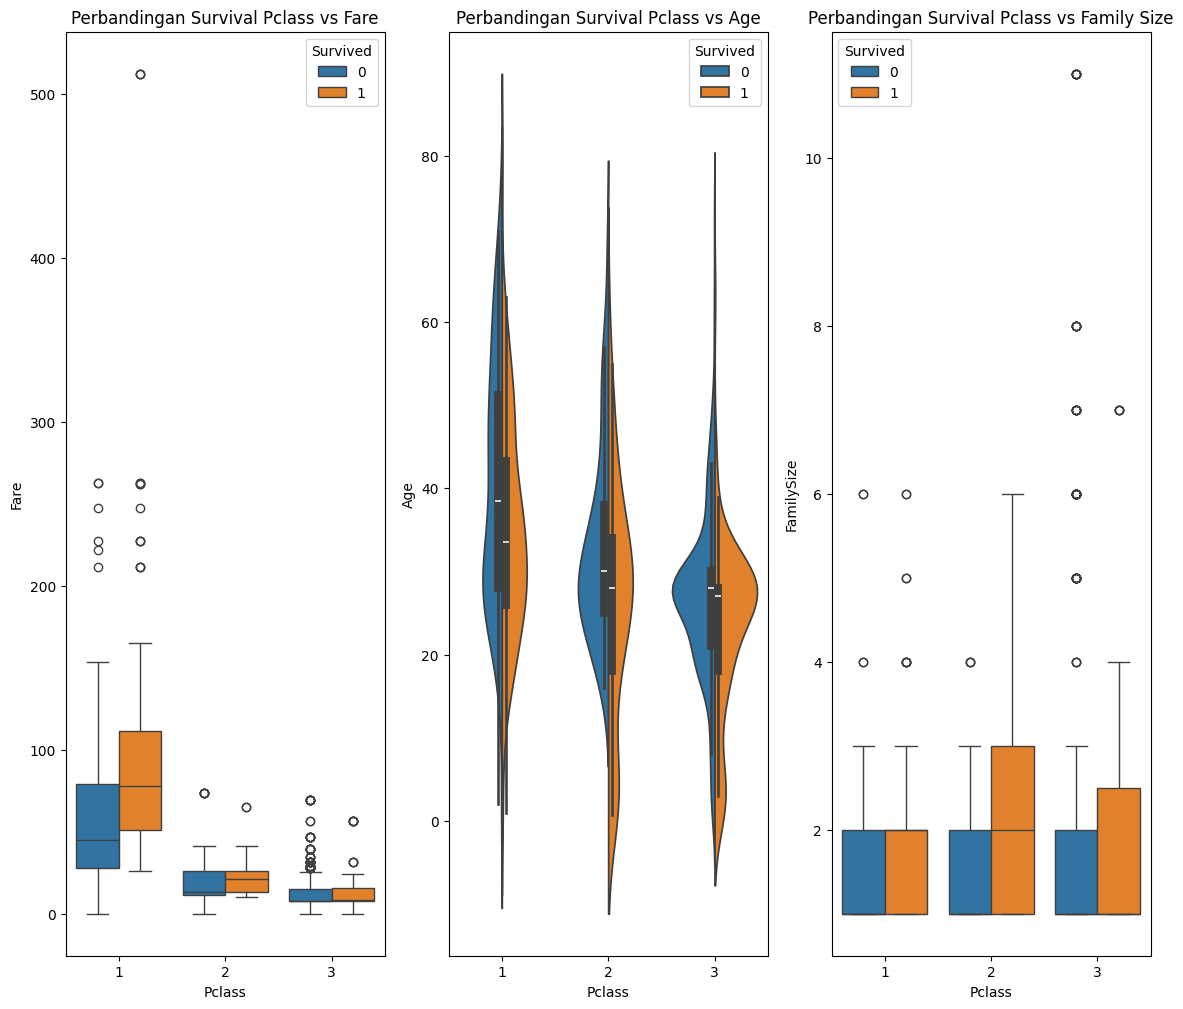

In [9]:
#grafik distribusi dari data kualitatif: Pclass
#Pclass cukup tinggi korelasinya dengan survival, berikut akan ditunjukkan perbandingan Pclass dengan bbrp fitur lain
fig, (axis1,axis2,axis3) = plt.subplots(1,3,figsize=(14,12))

sns.boxplot(x = 'Pclass', y = 'Fare', hue = 'Survived', data = data1, ax = axis1)
axis1.set_title('Perbandingan Survival Pclass vs Fare')

sns.violinplot(x = 'Pclass', y = 'Age', hue = 'Survived', data = data1, split = True, ax = axis2)
axis2.set_title('Perbandingan Survival Pclass vs Age')

sns.boxplot(x = 'Pclass', y ='FamilySize', hue = 'Survived', data = data1, ax = axis3)
axis3.set_title('Perbandingan Survival Pclass vs Family Size')

Text(0.5, 1.0, 'Perbandingan Survival Sex vs IsAlone')

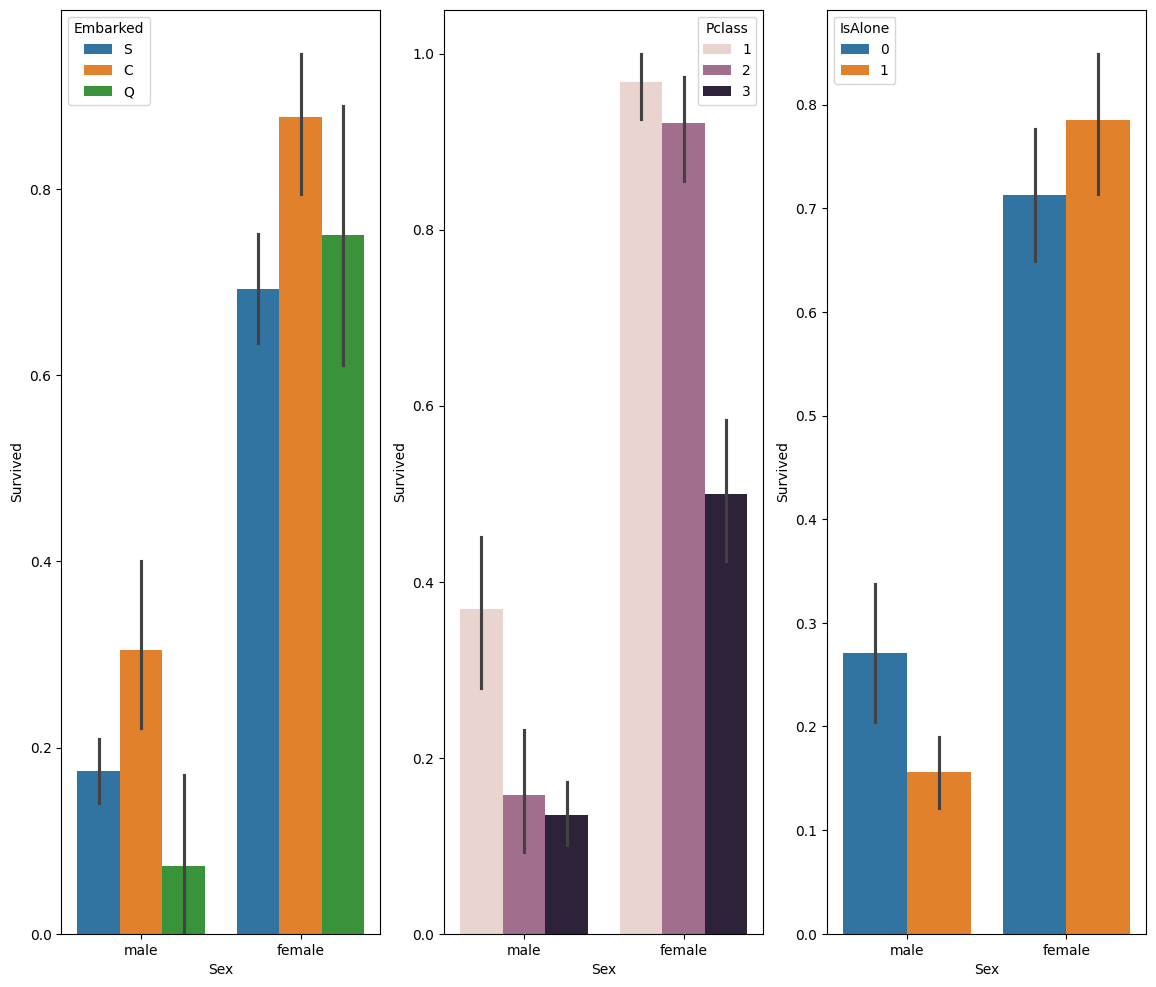

In [10]:
#grafik distribusi dari data kualitatif: Sex
#Sex cukup tinggi korelasinya dengan survival, berikut akan ditunjukkan perbandingan Sex dengan bbrp fitur lain
fig, qaxis = plt.subplots(1,3,figsize=(14,12))

sns.barplot(x = 'Sex', y = 'Survived', hue = 'Embarked', data=data1, ax = qaxis[0])
axis1.set_title('Perbandingan Survival Sex vs Embarked')

sns.barplot(x = 'Sex', y = 'Survived', hue = 'Pclass', data=data1, ax = qaxis[1])
axis1.set_title('Perbandingan Survival Sex vs Pclass')

sns.barplot(x = 'Sex', y = 'Survived', hue = 'IsAlone', data=data1, ax = qaxis[2])
axis1.set_title('Perbandingan Survival Sex vs IsAlone')

<Axes: xlabel='Pclass', ylabel='Survived'>

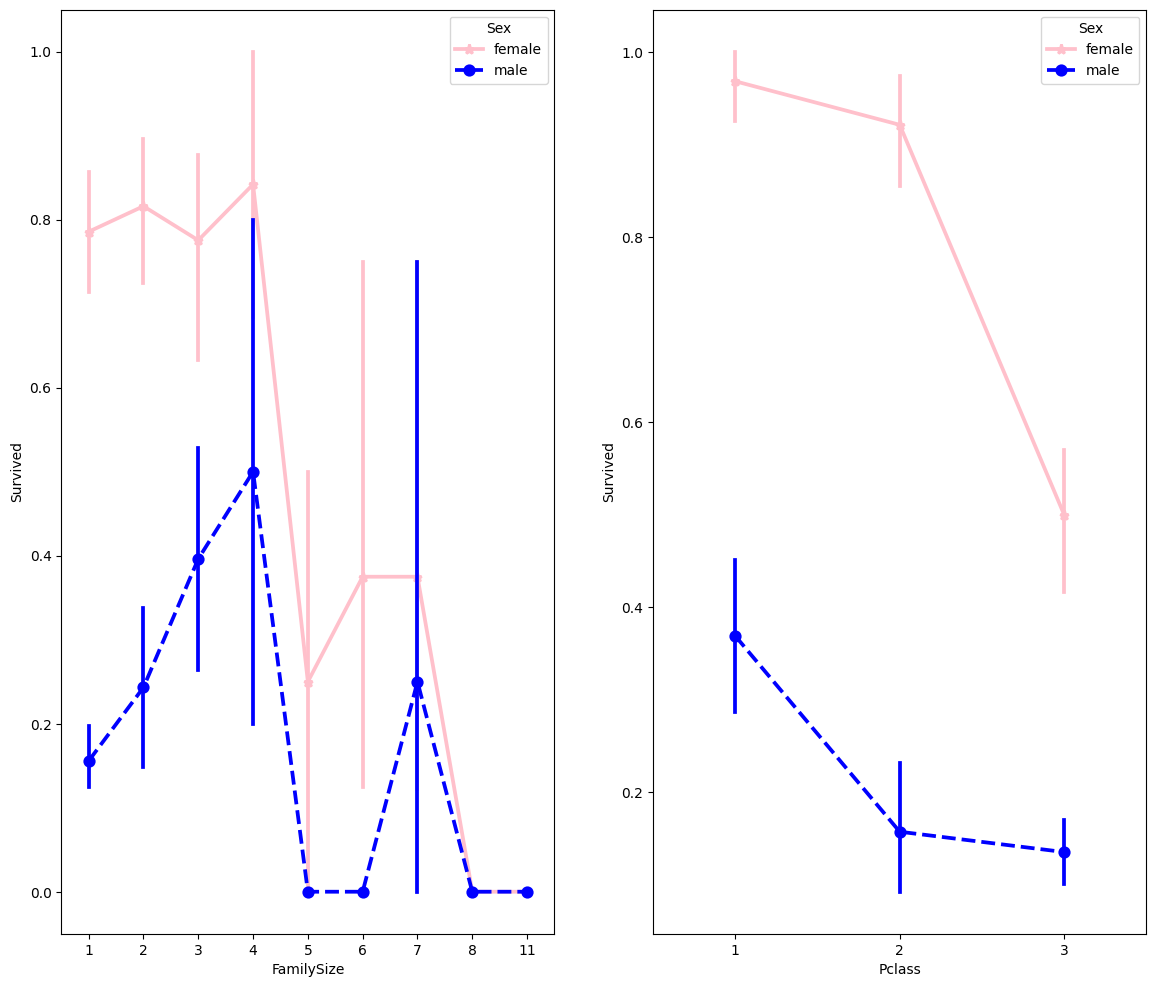

In [11]:
#contoh grafik perbandingan lainnya
fig, (maxis1, maxis2) = plt.subplots(1, 2,figsize=(14,12))

#bagaimana pengaruh faktor ukuran keluarga terhadap perbandingan jenis kelamin dan survival
sns.pointplot(x="FamilySize", y="Survived", hue="Sex", data=data1,
              palette={"male": "blue", "female": "pink"},
              markers=["*", "o"], linestyles=["-", "--"], ax = maxis1)

#bagaimana pengaruh faktor class terhadap perbandingan jenis kelamin dan survival
sns.pointplot(x="Pclass", y="Survived", hue="Sex", data=data1,
              palette={"male": "blue", "female": "pink"},
              markers=["*", "o"], linestyles=["-", "--"], ax = maxis2)

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:718: UserWarning: Using the pointplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:723: UserWarning: Using the pointplot function without specifying `hue_order` is likely to produce an incorrect plot.
  warnings.warn(warning)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95.0)` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95.0)` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95.0)` for the same effect.

  func(*plot_args, **plot_kwargs

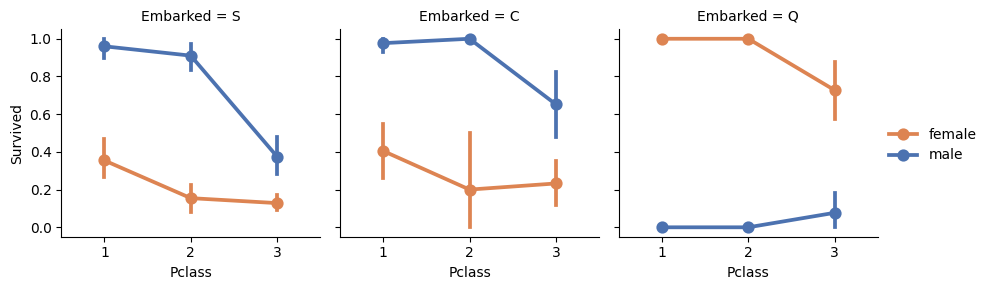

In [12]:
#bagaimana pengaruh faktor port keberangkatan terhadap perbandingan Pclass, sex, dan survival
#facetgrid: https://seaborn.pydata.org/generated/seaborn.FacetGrid.html
e = sns.FacetGrid(data1, col = 'Embarked')
e.map(sns.pointplot, 'Pclass', 'Survived', 'Sex', ci=95.0, palette = 'deep')
e.add_legend()

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(*plot_args, **plot_kwargs)


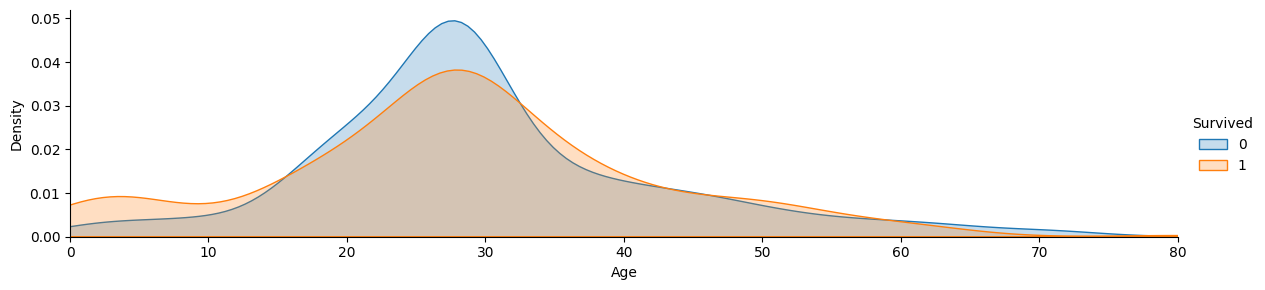

In [13]:
#plot distribusi dari usia penumpang yang selamat / tidak selamat
a = sns.FacetGrid( data1, hue = 'Survived', aspect=4 )
a.map(sns.kdeplot, 'Age', shade= True )
a.set(xlim=(0 , data1['Age'].max()))
a.add_legend()

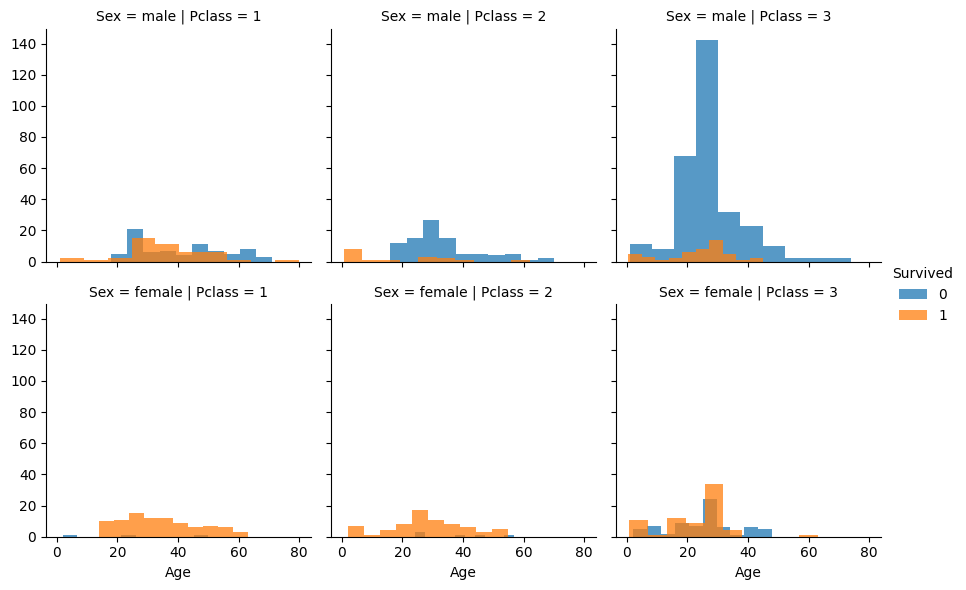

In [14]:
#perbandingan histogram dari sex, class, dan age dengan survival
h = sns.FacetGrid(data1, row = 'Sex', col = 'Pclass', hue = 'Survived')
h.map(plt.hist, 'Age', alpha = .75)
h.add_legend()

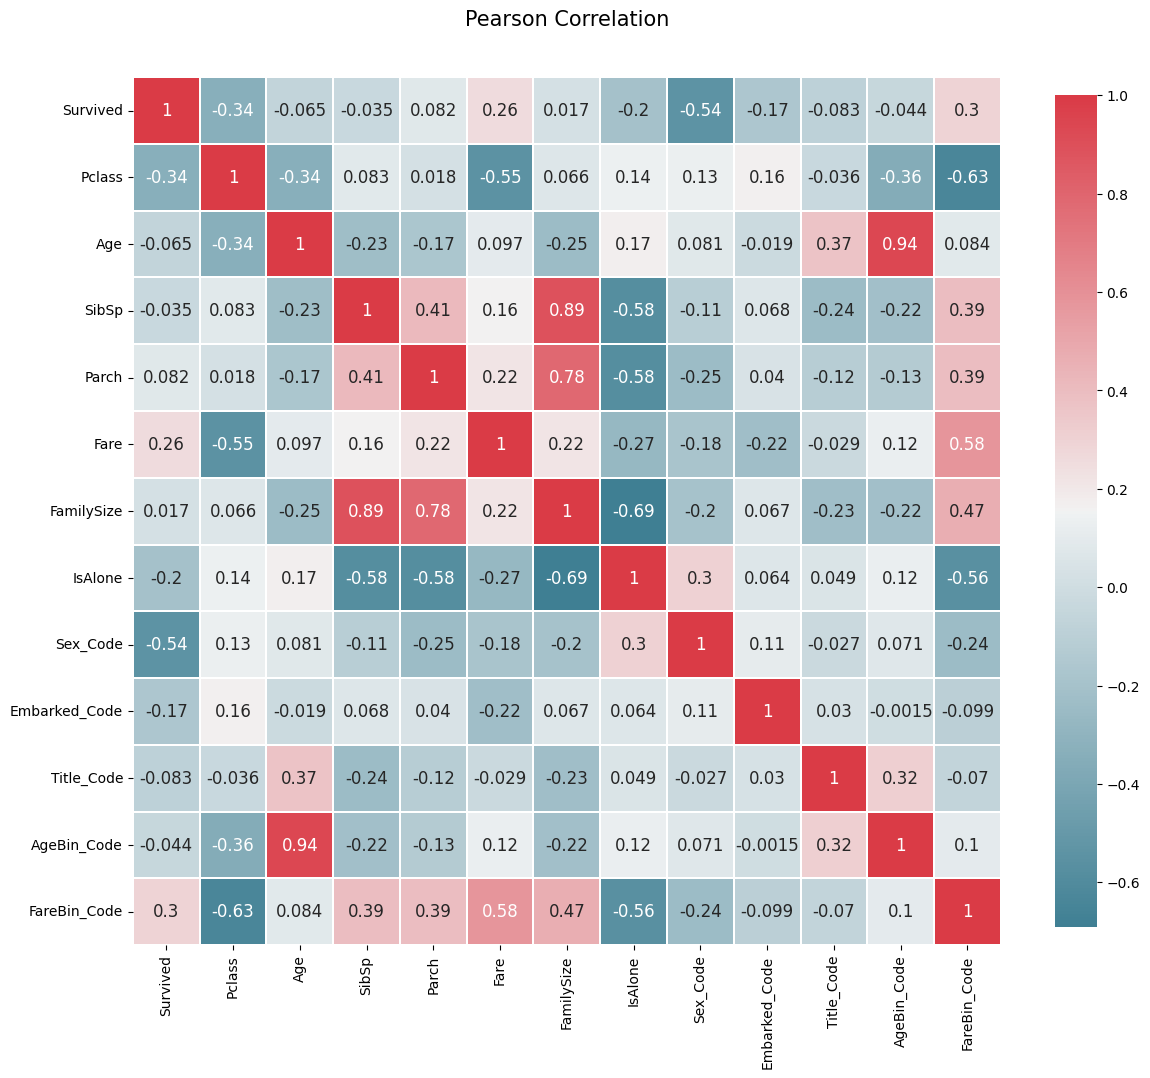

In [18]:
from sklearn.preprocessing import LabelEncoder
label = LabelEncoder()

# Mengubah data kategorikal (teks) menjadi numerik (angka)
data1['Sex_Code'] = label.fit_transform(data1['Sex'])
data1['Embarked_Code'] = label.fit_transform(data1['Embarked'])
data1['Title_Code'] = label.fit_transform(data1['Title'])
data1['AgeBin_Code'] = label.fit_transform(data1['AgeBin'])
data1['FareBin_Code'] = label.fit_transform(data1['FareBin'])
#Korelasi heatmap dari dataset
def correlation_heatmap(df):
    _ , ax = plt.subplots(figsize =(14, 12))
    colormap = sns.diverging_palette(220, 10, as_cmap = True)

    # Hanya dipilih fitur numerik saja
    numerical_df = df.select_dtypes(include=['number'])

    _ = sns.heatmap(
        numerical_df.corr(),
        cmap = colormap,
        square=True,
        cbar_kws={'shrink':.9 },
        ax=ax,
        annot=True,
        linewidths=0.1,vmax=1.0, linecolor='white',
        annot_kws={'fontsize':12 }
    )

    plt.title('Pearson Correlation', y=1.05, size=15)

correlation_heatmap(data1)